<a href="https://colab.research.google.com/github/ghadaPoly/Projet_ML/blob/main/ML_EDA_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⛳ Phase 1 : Chargement et exploration initiale du dataset
Dans cette étape, nous allons charger le dataset et effectuer une première analyse exploratoire afin de comprendre sa structure, la nature des variables et la qualité des données.

### Importation des bibliothèques

Nous commençons par importer les bibliothèques nécessaires :

*   pandas et numpy pour la manipulation des données
*   matplotlib et seaborn pour la visualisation
*   warnings pour ignorer certains avertissements inutiles



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#  ÉTAPE 1 : CHARGEMENT DU DATASET
Dans ce dataset, les valeurs "?" représentent des données manquantes.
Nous les remplaçons automatiquement par NaN pour faciliter leur traitement par la suite.


### Dimensions et aperçu des données
Nous affichons :
*   le nombre de lignes et de colonnes avec df.shape
*   les premières lignes avec df.head()

In [2]:
df = pd.read_csv("diabetic_data.csv", na_values="?")

print("Dimensions du dataset :", df.shape)

Dimensions du dataset : (101766, 50)


/tmp/ipykernel_15666/2775200164.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("diabetic_data.csv", na_values="?")


In [3]:
print("\nAperçu des premières lignes :")
print(df.head())


Aperçu des premières lignes :
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          

### Types des variables
Nous analysons les types de données avec :

* df.dtypes : type de chaque colonne
* df.dtypes.value_counts() : répartition des types

In [4]:
df.dtypes

,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [5]:
print("\nTypes des colonnes :")
print(df.dtypes.value_counts())


Types des colonnes :
object    37
int64     13
Name: count, dtype: int64


### Informations générales

La fonction df.info() donne :

* le nombre de valeurs non nulles
* le type de chaque colonne
* la mémoire utilisée

In [6]:
print("\nInformations générales :")
df.info()


Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 

###Échantillon aléatoire

Nous affichons 5 lignes aléatoires avec df.sample().

In [7]:
print("\n 5 lignes aléatoires ")
print(df.sample(5, random_state=42))


── 5 lignes aléatoires ─────────────────────────────────
       encounter_id  patient_nbr             race  gender      age weight  \
35956     110939484     19274094        Caucasian  Female  [70-80)    NaN   
60927     170328306     65634327        Caucasian    Male  [50-60)    NaN   
79920     245688426    100657359        Caucasian  Female  [60-70)    NaN   
50078     150826224     83144448        Caucasian    Male  [30-40)    NaN   
44080     135993852     65234214  AfricanAmerican  Female  [60-70)    NaN   

       admission_type_id  discharge_disposition_id  admission_source_id  \
35956                  1                         1                    6   
60927                  1                         1                    1   
79920                  3                         6                    1   
50078                  2                         1                    1   
44080                  1                         2                    7   

       time_in_hospital  ...

###Analyse des valeurs manquantes

Nous calculons :

* le nombre de valeurs manquantes par colonne
* le pourcentage de valeurs manquantes

Cette étape est essentielle pour préparer le nettoyage des données.

In [8]:
nan_count = df.isnull().sum()
print(nan_count)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
nan_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(nan_pct)

encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.86
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.08
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.35
diag_3                       1.40
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.28
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride                  0.00
acetohexamide 

### Détection des doublons
* Nous vérifions le nombre de lignes dupliquées avec df.duplicated().

Les doublons peuvent fausser l’analyse et devront être traités.

In [10]:
print("\n Doublons ")
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")



── Doublons ────────────────────────────────────────────
Nombre de lignes dupliquées : 0


### Cardinalité des variables

Nous affichons le nombre de valeurs uniques par colonne avec df.nunique().

Cela permet :

* d’identifier les variables à forte cardinalité
* de détecter des identifiants uniques ou inutiles

In [11]:
print("\n Nombre de valeurs uniques par colonne ")
print(df.nunique().sort_values(ascending=False))



── Nombre de valeurs uniques par colonne ───────────────
encounter_id                101766
patient_nbr                  71518
diag_3                         789
diag_2                         748
diag_1                         716
num_lab_procedures             118
num_medications                 75
medical_specialty               72
number_outpatient               39
number_emergency                33
discharge_disposition_id        26
number_inpatient                21
payer_code                      17
admission_source_id             17
number_diagnoses                16
time_in_hospital                14
age                             10
weight                           9
admission_type_id                8
num_procedures                   7
race                             5
glyburide-metformin              4
repaglinide                      4
metformin                        4
chlorpropamide                   4
nateglinide                      4
pioglitazone                    

### Statistiques descriptives
* df.describe() :  statistiques des variables numériques (moyenne, min, max…)
* df.describe(include='object') : résumé des variables catégorielles

In [12]:
print("\n── Statistiques descriptives (colonnes numériques) ─────")
print(df.describe().round(2))


── Statistiques descriptives (colonnes numériques) ─────
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05          101766.00   
mean   1.652016e+08  5.433040e+07               2.02   
std    1.026403e+08  3.869636e+07               1.45   
min    1.252200e+04  1.350000e+02               1.00   
25%    8.496119e+07  2.341322e+07               1.00   
50%    1.523890e+08  4.550514e+07               1.00   
75%    2.302709e+08  8.754595e+07               3.00   
max    4.438672e+08  1.895026e+08               8.00   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count                 101766.00            101766.00         101766.00   
mean                       3.72                 5.75              4.40   
std                        5.28                 4.06              2.99   
min                        1.00                 1.00              1.00   
25%                        1.00                 1.00              2

In [13]:
print("\n── Statistiques descriptives (colonnes catégorielles) ──")
print(df.describe(include='object'))


── Statistiques descriptives (colonnes catégorielles) ──
             race  gender      age    weight payer_code medical_specialty  \
count       99493  101766   101766      3197      61510             51817   
unique          5       3       10         9         17                72   
top     Caucasian  Female  [70-80)  [75-100)         MC  InternalMedicine   
freq        76099   54708    26068      1336      32439             14635   

        diag_1  diag_2  diag_3 max_glu_serum  ... citoglipton insulin  \
count   101745  101408  100343          5346  ...      101766  101766   
unique     716     748     789             3  ...           1       4   
top        428     276     250          Norm  ...          No      No   
freq      6862    6752   11555          2597  ...      101766   47383   

       glyburide-metformin glipizide-metformin glimepiride-pioglitazone  \
count               101766              101766                   101766   
unique                   4              


#  ÉTAPE 2 : VALEURS MANQUANTES
Dans cette étape, nous analysons les valeurs manquantes présentes dans le dataset afin d’identifier les colonnes problématiques et préparer leur traitement.

### Pourquoi analyser les valeurs manquantes ?

Les valeurs manquantes peuvent :

* fausser les résultats des analyses
* perturber les modèles de machine learning
* nécessiter un traitement spécifique (suppression ou imputation)

Il est donc essentiel de les détecter et de mesurer leur importance.


###Calcul des valeurs manquantes

Nous créons un tableau récapitulatif contenant :

* le nombre de valeurs manquantes par colonne
* le pourcentage de valeurs manquantes

Cela est réalisé à l’aide de :

df.isnull().sum() : nombre de valeurs manquantes
division par la taille du dataset pour obtenir le pourcentage

In [14]:
# Calcul du nombre et pourcentage de valeurs manquantes par colonne
valeurs_manquantes = pd.DataFrame({
    'Nombre'     : df.isnull().sum(),
    'Pourcentage': (df.isnull().sum() / len(df) * 100).round(2)
})

###Filtrage des colonnes concernées

Nous conservons uniquement les colonnes qui contiennent au moins une valeur manquante.

Cela permet de se concentrer uniquement sur les variables à problème.

Ensuite, nous trions les colonnes par ordre décroissant de pourcentage pour :

* identifier les colonnes les plus affectées
* prioriser leur traitement

In [15]:
# On garde seulement les colonnes qui ont au moins 1 valeur manquante
valeurs_manquantes = valeurs_manquantes[valeurs_manquantes['Nombre'] > 0]
valeurs_manquantes = valeurs_manquantes.sort_values('Pourcentage', ascending=False)

print("Colonnes avec valeurs manquantes :\n")
print(valeurs_manquantes)

Colonnes avec valeurs manquantes :

                   Nombre  Pourcentage
weight              98569        96.86
max_glu_serum       96420        94.75
A1Cresult           84748        83.28
medical_specialty   49949        49.08
payer_code          40256        39.56
race                 2273         2.23
diag_3               1423         1.40
diag_2                358         0.35
diag_1                 21         0.02


### Visualisation des valeurs manquantes

Nous utilisons un graphique en barres horizontales pour représenter le pourcentage de valeurs manquantes par colonne.

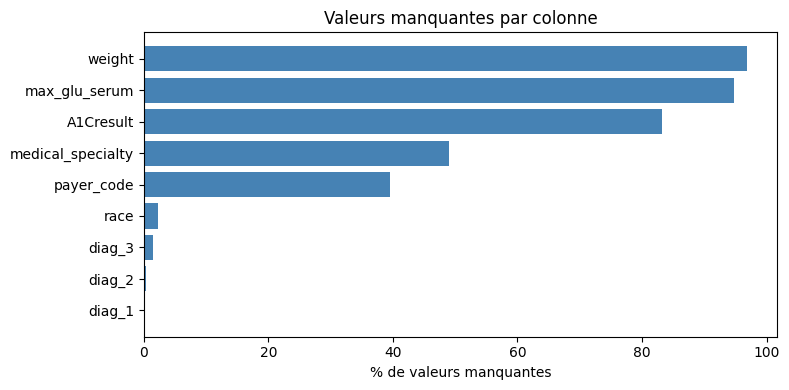

In [16]:

plt.figure(figsize=(8, 4))
plt.barh(valeurs_manquantes.index, valeurs_manquantes['Pourcentage'], color='steelblue')
plt.xlabel('% de valeurs manquantes')
plt.title('Valeurs manquantes par colonne')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#  ÉTAPE 3 : STATISTIQUES DESCRIPTIVES
Dans cette étape, nous explorons les statistiques des variables numériques et analysons la distribution des variables cibles du dataset.

###Analyse des variables numériques

Nous sélectionnons un ensemble de colonnes numériques pertinentes, telles que :

* durée d’hospitalisation (time_in_hospital)
* nombre d’examens (num_lab_procedures)
* nombre de médicaments (num_medications)
* nombre de diagnostics (number_diagnoses)
etc.

L’objectif est de résumer ces variables à l’aide de statistiques descriptives.

####Statistiques descriptives

La fonction **describe()** permet d’obtenir :

* la moyenne **(mean) :** valeur centrale
* l’écart-type **(std) :** dispersion des données
* les valeurs minimales et maximales
* les **quartiles** (25%, 50%, 75%)

Cela permet de :

* comprendre la distribution des données
* détecter d’éventuelles valeurs aberrantes
* identifier les variables avec une forte variabilité

In [17]:
# Sélectionner uniquement les colonnes numériques
colonnes_numeriques = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                       'num_medications', 'number_outpatient', 'number_emergency',
                       'number_inpatient', 'number_diagnoses']

print("Statistiques descriptives :")
print(df[colonnes_numeriques].describe().round(2))

Statistiques descriptives :
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count         101766.00           101766.00       101766.00        101766.00   
mean               4.40               43.10            1.34            16.02   
std                2.99               19.67            1.71             8.13   
min                1.00                1.00            0.00             1.00   
25%                2.00               31.00            0.00            10.00   
50%                4.00               44.00            1.00            15.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count          101766.00         101766.00         101766.00         101766.00  
mean                0.37              0.20              0.64              7.42  
std     

### Analyse des variables cibles

Nous visualisons ensuite la distribution de deux variables importantes :

1. **readmitted** : indique si un patient a été réadmis
2. **change** : indique s’il y a eu un changement dans le traitement

### Visualisation des distributions

Nous utilisons deux diagrammes en barres affichés côte à côte pour :

* observer la répartition des classes

Cela permet de :
***détecter un éventuel déséquilibre des classes***

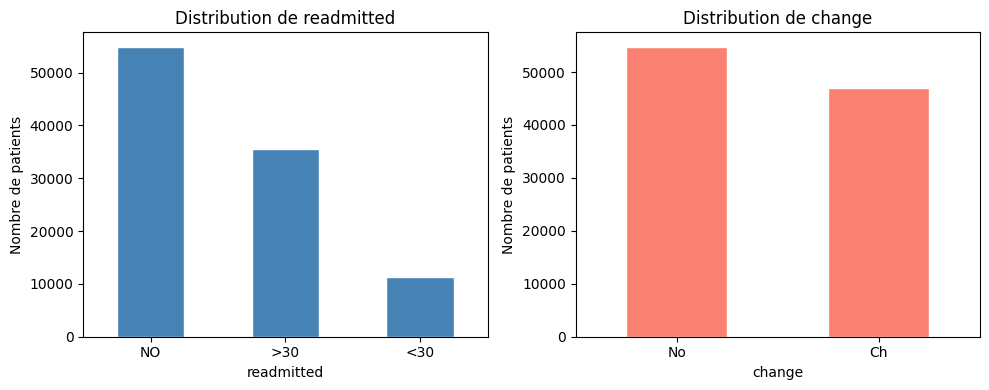

In [19]:
# Visualisation des deux cibles côte à côte
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['readmitted'].value_counts().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de readmitted')
axes[0].set_ylabel('Nombre de patients')
axes[0].tick_params(axis='x', rotation=0)

df['change'].value_counts().plot(kind='bar', ax=axes[1],
    color='salmon', edgecolor='white')
axes[1].set_title('Distribution de change')
axes[1].set_ylabel('Nombre de patients')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



#  ÉTAPE 4 : DISTRIBUTIONS (HISTOGRAMMES)
Dans cette étape, nous étudions la répartition des valeurs des variables numériques à l’aide d’histogrammes.

###Pourquoi analyser les distributions ?

L’analyse des distributions permet de :

1. détecter des valeurs aberrantes (outliers)
2. identifier des variables nécessitant une transformation (normalisation…)

C’est une étape essentielle avant toute modélisation.


###Visualisation avec des histogrammes

Pour chaque variable numérique, nous traçons un histogramme qui montre :

1. l’axe horizontal → les valeurs de la variable
2. l’axe vertical → leur fréquence (nombre d’occurrences)

Cela permet de visualiser comment les données sont réparties.

### Ajout de la médiane

Nous ajoutons une ligne verticale rouge représentant la médiane de chaque variable.

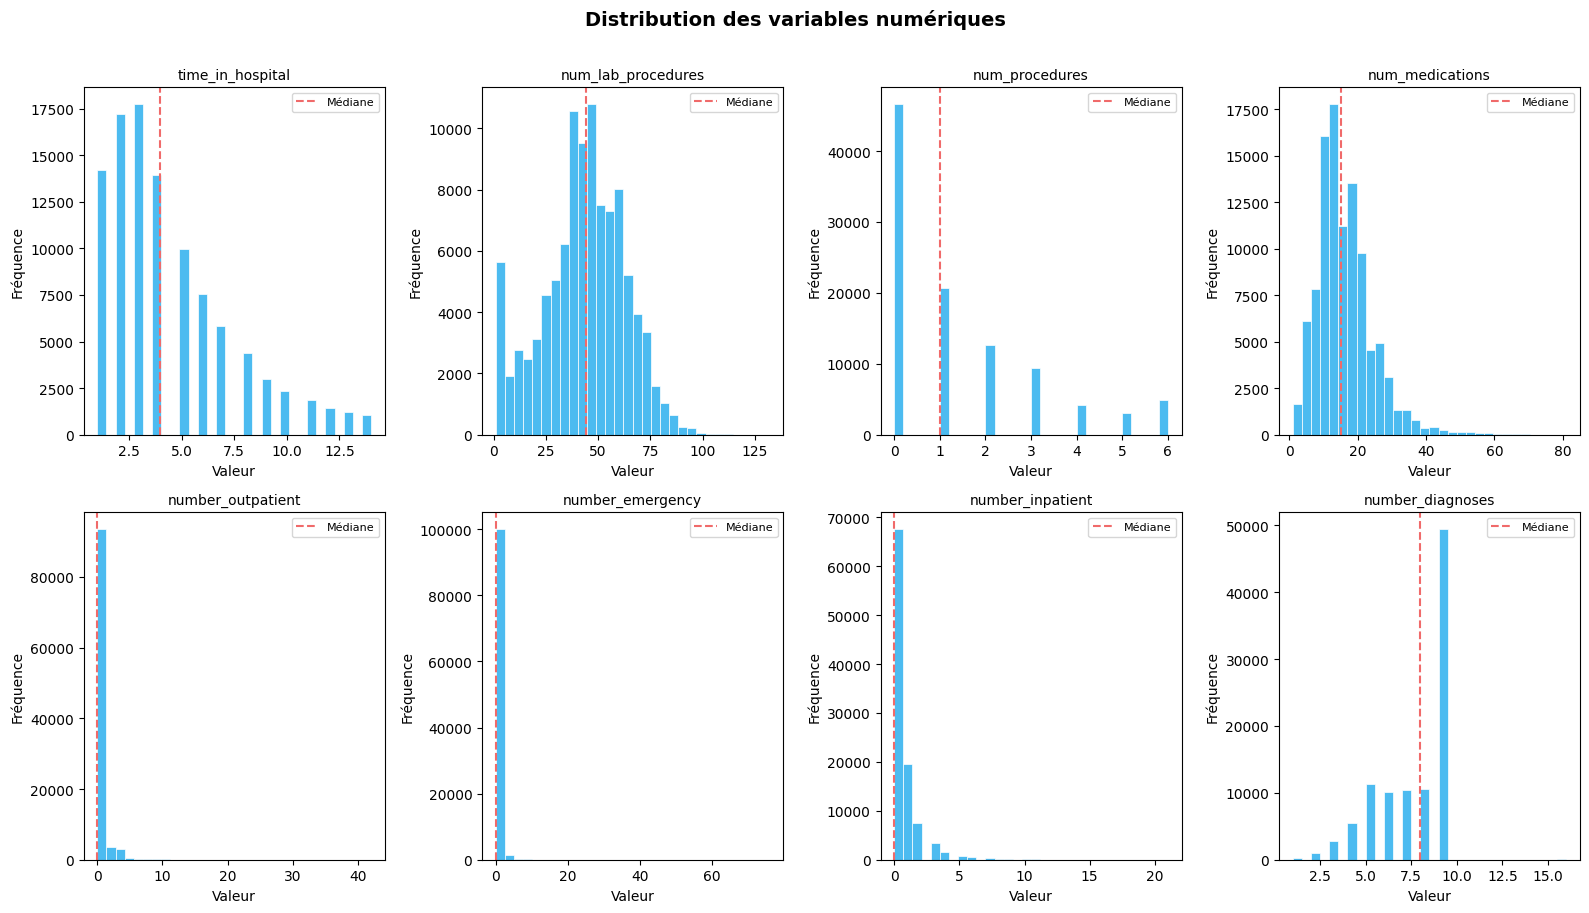

In [42]:

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(colonnes_numeriques[:-2]):
    axes[i].hist(df[col], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')
    axes[i].axvline(df[col].median(), color=RED, linestyle='--',
                    linewidth=1.5, label='Médiane')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution des variables numériques',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


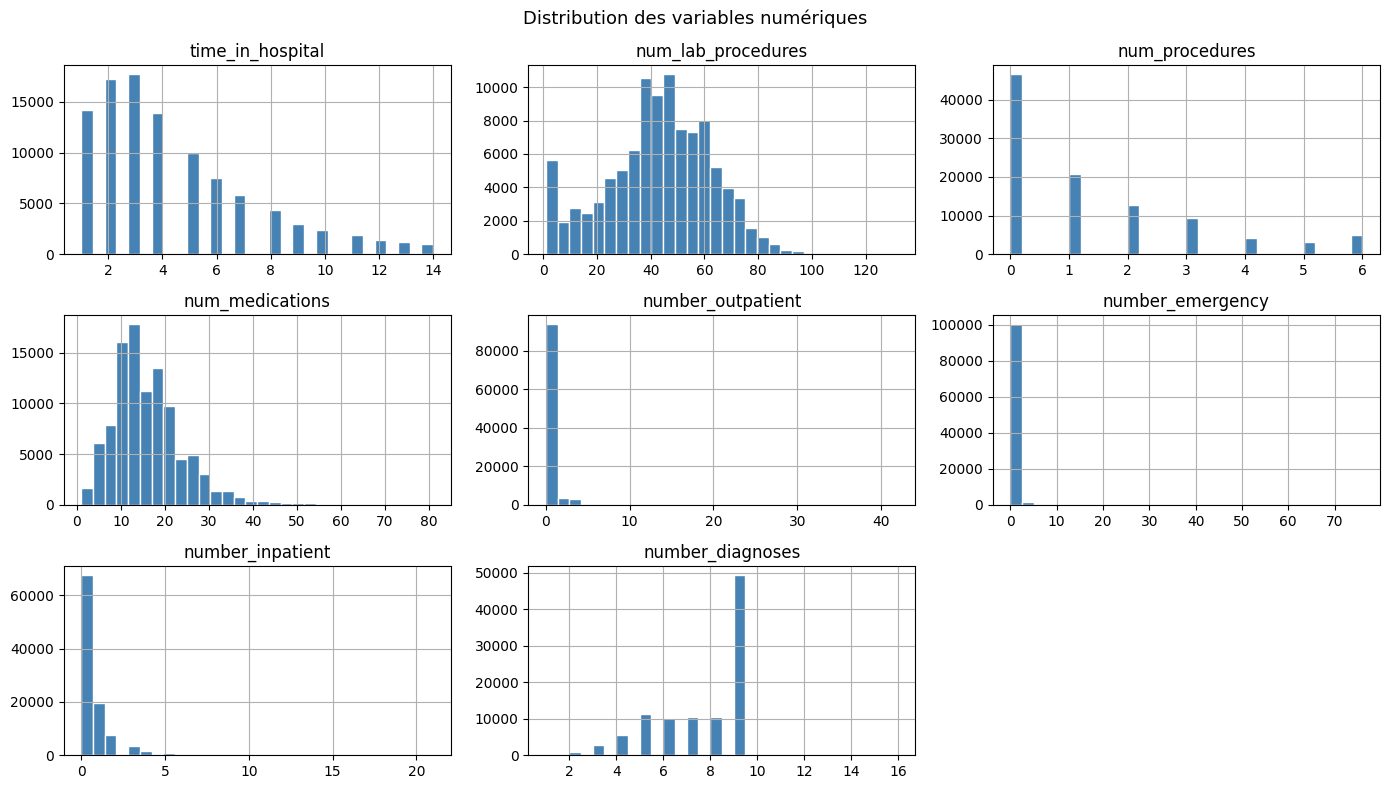

In [20]:

#df[colonnes_numeriques].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
#plt.suptitle('Distribution des variables numériques', fontsize=13)
#plt.tight_layout()
#plt.show()



#  ÉTAPE 5 : DÉTECTION DES OUTLIERS
Dans cette étape, nous identifions les valeurs extrêmes (outliers) présentes dans les variables numériques.

###Pourquoi détecter les outliers ?

Les outliers peuvent :

* fausser les statistiques (moyenne, variance…)
* perturber les modèles de machine learning
* indiquer des erreurs de saisie ou des cas particuliers


###Visualisation avec les boxplots

Nous utilisons des boxplots (diagrammes en boîte) pour chaque variable numérique.

Un boxplot affiche :

* la **médiane** (ligne centrale)
* les **quartiles** Q1 et Q3
* les **moustaches** (limites des valeurs normales)
* les points isolés : **outliers potentiels**

*Les valeurs situées en dehors des moustaches sont considérées comme suspectes.*

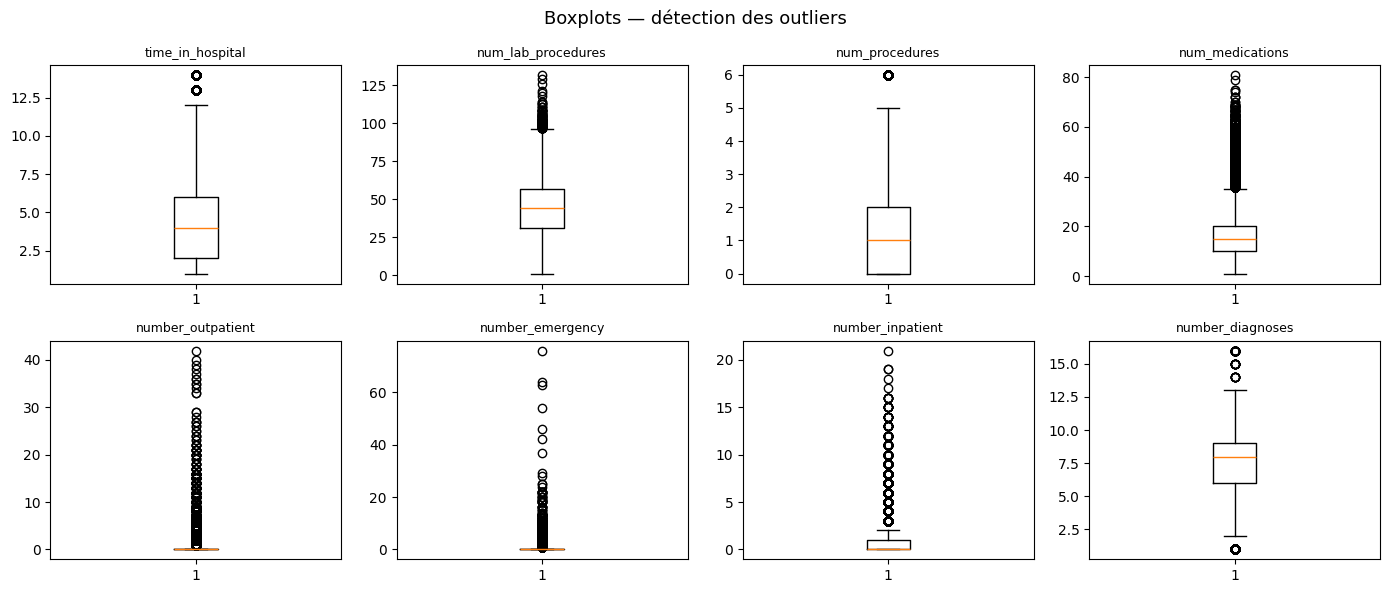

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(colonnes_numeriques):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplots — détection des outliers', fontsize=13)
plt.tight_layout()
plt.show()

###Méthode IQR pour détecter les outliers

Nous utilisons ensuite une méthode statistique appelée IQR (Interquartile Range) :

+ IQR = Q3 − Q1
+ Limite basse = Q1 − 1.5 × IQR
+ Limite haute = Q3 + 1.5 × IQR

Toute valeur en dehors de cet intervalle est considérée comme un outlier.

In [22]:

print("Nombre d'outliers par colonne :\n")
for col in colonnes_numeriques:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<25} : {n_outliers} outliers ({n_outliers / len(df) * 100:.1f}%)")

Nombre d'outliers par colonne (méthode IQR) :

  time_in_hospital          → 2252 outliers (2.2%)
  num_lab_procedures        → 143 outliers (0.1%)
  num_procedures            → 4954 outliers (4.9%)
  num_medications           → 2557 outliers (2.5%)
  number_outpatient         → 16739 outliers (16.4%)
  number_emergency          → 11383 outliers (11.2%)
  number_inpatient          → 7049 outliers (6.9%)
  number_diagnoses          → 281 outliers (0.3%)


#  ÉTAPE 6 : ANALYSE DES VARIABLES CATÉGORIELLES
Dans cette étape, nous analysons les variables catégorielles en observant la fréquence de chaque catégorie.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BLUE = '#4CBBF0'
RED  = '#F06A6A'


###Distribution des catégories

Pour chaque variable catégorielle :

+ nous calculons le nombre d’occurrences de chaque catégorie avec value_counts()
+ nous affichons ces fréquences sous forme de diagrammes en barres

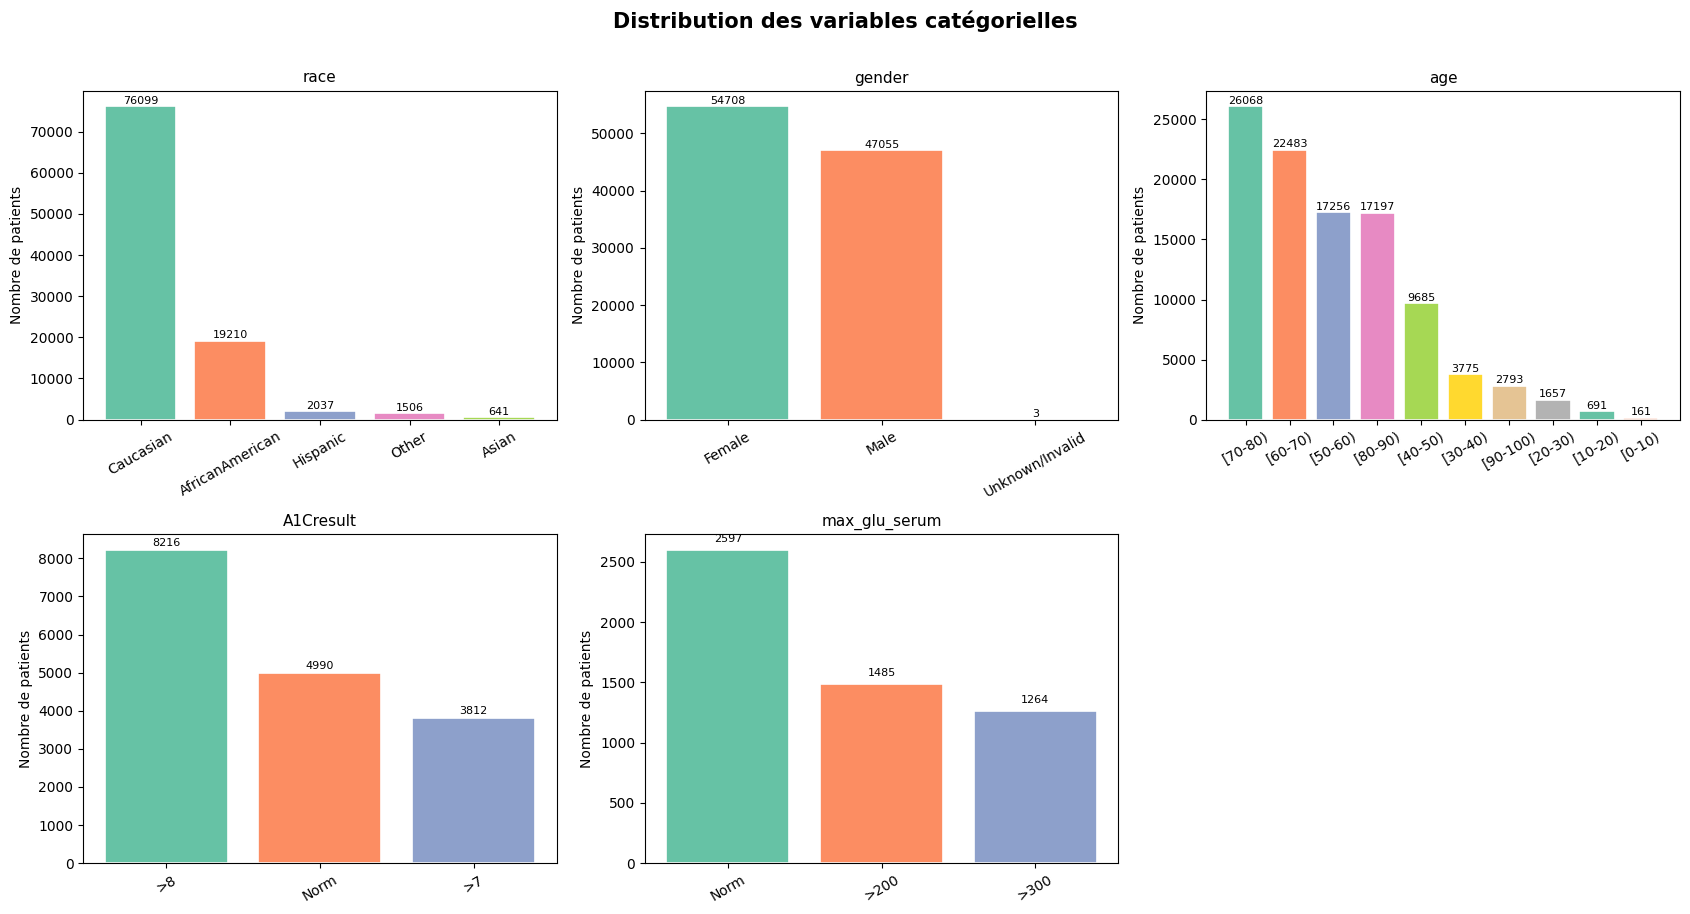

In [44]:
palette = sns.color_palette('Set2')

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    val_counts = df[col].value_counts()
    bars = axes[i].bar(val_counts.index, val_counts.values,
                       color=palette[:len(val_counts)],
                       edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Nombre de patients')
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, h + 50,
                     str(int(h)), ha='center', va='bottom', fontsize=8)

# Cacher le 6e sous-graphique (on n'a que 5 colonnes)
axes[5].set_visible(False)

plt.suptitle('Distribution des variables catégorielles',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#  ÉTAPE 7 : ANALYSE DES VARIABLES CIBLES
Dans cette étape, nous nous concentrons sur les variables cibles du modèle : readmitted et change.

Nous transformons les variables cibles en format binaire (0 / 1) :

1. **readmitted_bin** :
+ 1 : patient ré-hospitalisé en moins de 30 jours (<30)
+ 0 : sinon (NO ou >30)
2. **change_bin** :
+ 1 : changement de traitement (Ch)
+ 0 : pas de changement (No)

Cette transformation est nécessaire pour les modèles de classification.

###Analyse des distributions

Nous affichons :

+ les distributions originales
+ les distributions après binarisation

Puis nous visualisons les deux variables avec des diagrammes en barres.

In [24]:

# --- Binarisation des cibles ---
# readmitted : on garde seulement "<30" comme cas positif (ré-hospitalisé dans les 30 jours)
# "NO" et ">30" deviennent 0
df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)

# change : "Ch" = traitement changé (1), "No" = pas de changement (0)
df['change_bin'] = (df['change'] == 'Ch').astype(int)

print("Distribution de readmitted (original) :")
print(df['readmitted'].value_counts())

print("\nDistribution de readmitted_bin (binarisé) :")
print(df['readmitted_bin'].value_counts())

print("\nDistribution de change_bin :")
print(df['change_bin'].value_counts())

Distribution de readmitted (original) :
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Distribution de readmitted_bin (binarisé) :
readmitted_bin
0    90409
1    11357
Name: count, dtype: int64

Distribution de change_bin :
change_bin
0    54755
1    47011
Name: count, dtype: int64


###Détection du déséquilibre

Cette analyse permet de vérifier si les classes sont :

+ équilibrées
+ ou déséquilibrées (ce qui peut impacter les performances du modèle)

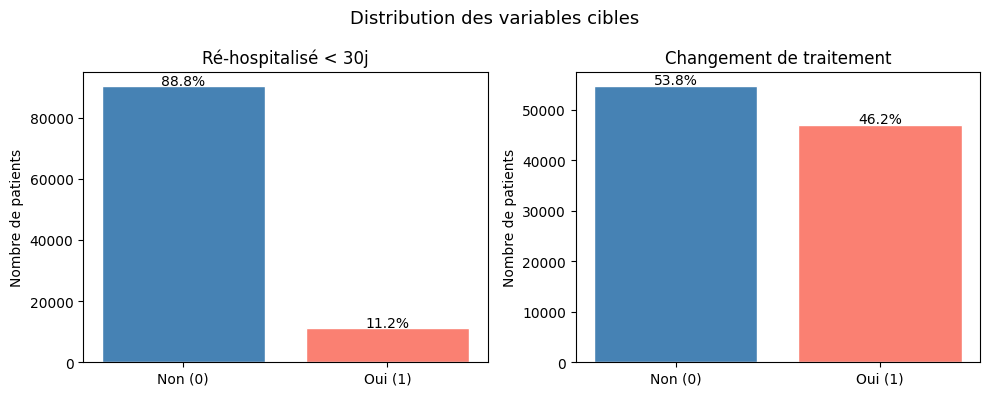

In [25]:
# Visualisation des deux cibles
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, titre in zip(axes,
                           ['readmitted_bin', 'change_bin'],
                           ['Ré-hospitalisé < 30j', 'Changement de traitement']):
    counts = df[col].value_counts().sort_index()
    ax.bar(['Non (0)', 'Oui (1)'], counts.values, color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(titre)
    ax.set_ylabel('Nombre de patients')
    # Afficher le % sur chaque barre
    for j, val in enumerate(counts.values):
        ax.text(j, val + 300, f'{val / len(df) * 100:.1f}%', ha='center', fontsize=10)

plt.suptitle('Distribution des variables cibles', fontsize=13)
plt.tight_layout()
plt.show()

Nous étudions les **combinaisons** possibles entre readmitted_bin et change_bin.

Cela permet d’identifier 4 profils :

**+ (0,0), (0,1), (1,0), (1,1)**

In [26]:
print("\nCombinations des deux cibles :")
print(df.groupby(['readmitted_bin', 'change_bin']).size()
        .reset_index(name='count')
        .assign(pct=lambda x: (x['count'] / len(df) * 100).round(1)))


Combinations des deux cibles :
   readmitted_bin  change_bin  count   pct
0               0           0  48956  48.1
1               0           1  41453  40.7
2               1           0   5799   5.7
3               1           1   5558   5.5



#  ÉTAPE 8 : CORRÉLATIONS
On mesure le lien linéaire entre les variables numériques et nos deux cibles

###Pourquoi analyser les corrélations ?

L’analyse des corrélations permet de :

+ mesurer la force et le sens de la relation entre deux variables
+ identifier les variables les plus influentes sur les cibles
+ détecter des variables redondantes (fortement corrélées entre elles)

Cela aide à améliorer la sélection des variables pour le modèle.

###Matrice de corrélation (heatmap)
Nous calculons une matrice de corrélation incluant :

+ *les variables numériques*
+ *les deux variables cibles* (readmitted_bin et change_bin)

Puis nous la visualisons avec une heatmap :

+ **rouge** : corrélation positive
+ **bleu** : corrélation négative

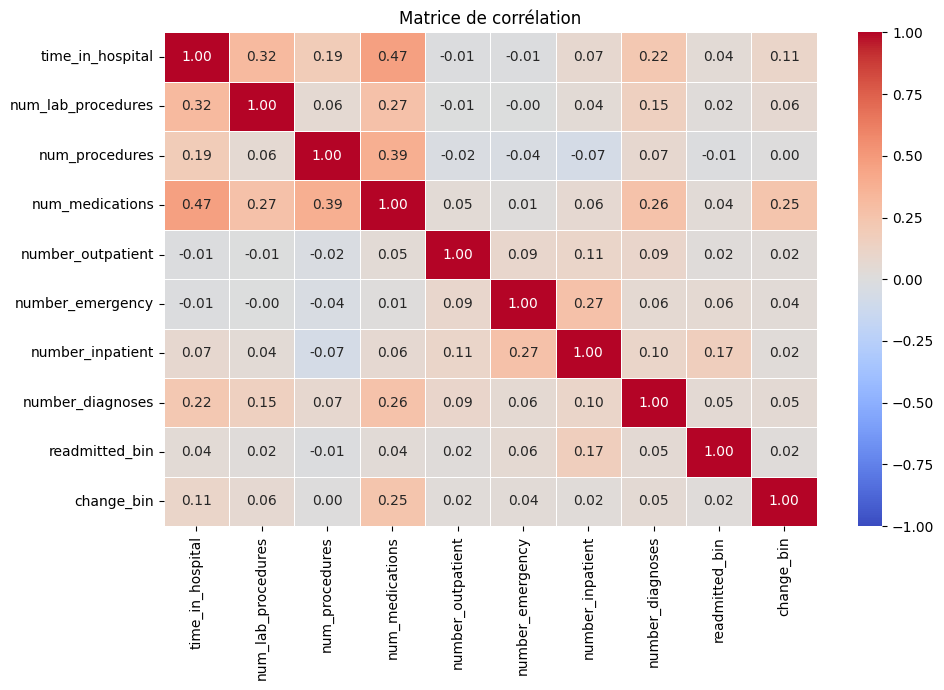

In [27]:
cols_corr = colonnes_numeriques + ['readmitted_bin', 'change_bin']
corr = df[cols_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr,
            annot=True,       # afficher les valeurs
            fmt='.2f',        # 2 décimales
            cmap='coolwarm',  # rouge = corrélation positive, bleu = négative
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()



###Corrélation avec les variables cibles

Pour une meilleure lisibilité, nous extrayons ensuite :

+ les corrélations avec readmitted_bin
+ les corrélations avec change_bin

In [28]:
# Corrélation avec les cibles uniquement (plus lisible)
print("Corrélation avec readmitted_bin :")
print(corr['readmitted_bin'].drop(['readmitted_bin', 'change_bin'])
                            .sort_values(key=abs, ascending=False).round(3))



Corrélation avec readmitted_bin :
number_inpatient      0.165
number_emergency      0.061
number_diagnoses      0.050
time_in_hospital      0.044
num_medications       0.038
num_lab_procedures    0.020
number_outpatient     0.019
num_procedures       -0.012
Name: readmitted_bin, dtype: float64


In [29]:
print("\nCorrélation avec change_bin :")
print(corr['change_bin'].drop(['readmitted_bin', 'change_bin'])
                        .sort_values(key=abs, ascending=False).round(3))


Corrélation avec change_bin :
num_medications       0.247
time_in_hospital      0.109
num_lab_procedures    0.064
number_diagnoses      0.053
number_emergency      0.039
number_outpatient     0.025
number_inpatient      0.024
num_procedures        0.004
Name: change_bin, dtype: float64


###Coefficient de corrélation de Pearson

Le coefficient de Pearson varie entre :

* **+1** : corrélation positive forte
* **0** : aucune corrélation
* **-1** : corrélation négative forte

Plus la valeur est proche de ±1, plus la relation est forte

⚠️ **Limite importante**

La corrélation de Pearson mesure uniquement les relations linéaires.
Elle ne détecte pas les relations non linéaires.

In [40]:
def plot_pearson_for_targets(df, targets, num_cols, BLUE='#4CBBF0', RED='#F06A6A'):
    """
    Affiche la corrélation de Pearson pour plusieurs variables cibles

    Parameters:
    - df : DataFrame
    - targets : liste des cibles (ex: ['readmitted_bin', 'change_bin'])
    - num_cols : colonnes numériques (incluant les cibles)
    """

    from matplotlib.patches import Patch

    for target in targets:
        # Calcul corrélation
        corr_target = (df[num_cols].corr()[target]
                                    .drop(target)
                                    .sort_values())

        # Couleurs
        colors = [RED if v > 0 else BLUE for v in corr_target.values]

        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(corr_target.index, corr_target.values,
                       color=colors, edgecolor='white', linewidth=1)

        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Coefficient de Corrélation de Pearson')
        ax.set_title(f'Corrélation des variables avec {target}',
                     fontsize=13, fontweight='bold')

        # Valeurs sur les barres
        for bar, val in zip(bars, corr_target.values):
            offset = 0.002 if val >= 0 else -0.002
            ax.text(val + offset,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}',
                    va='center',
                    ha='left' if val >= 0 else 'right',
                    fontsize=9)

        # Légende
        legend_elements = [
            Patch(facecolor=RED, label='Corrélation positive (+)'),
            Patch(facecolor=BLUE, label='Corrélation négative (-)')
        ]
        ax.legend(handles=legend_elements, loc='lower right')

        plt.tight_layout()
        plt.show()

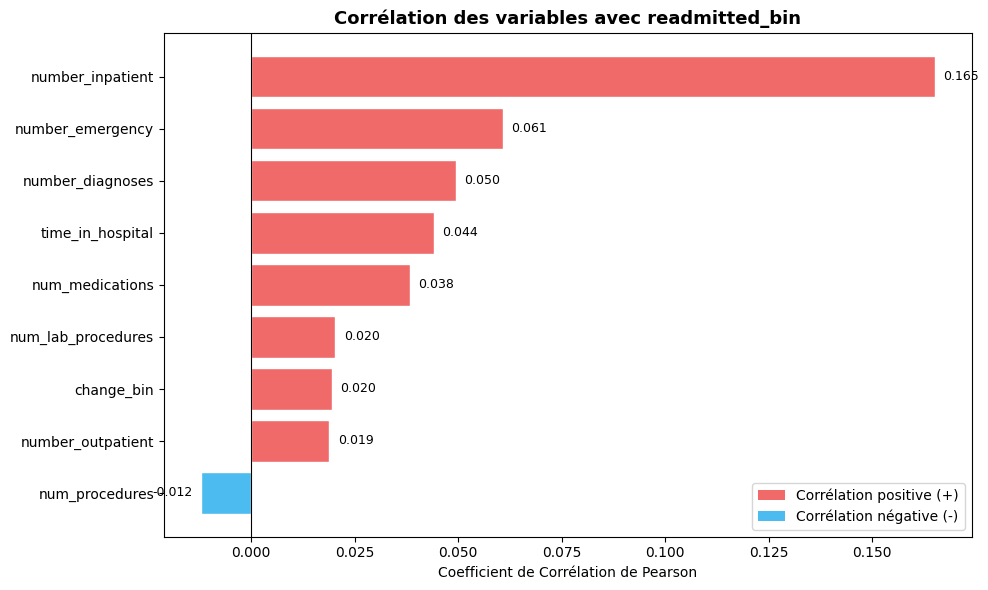

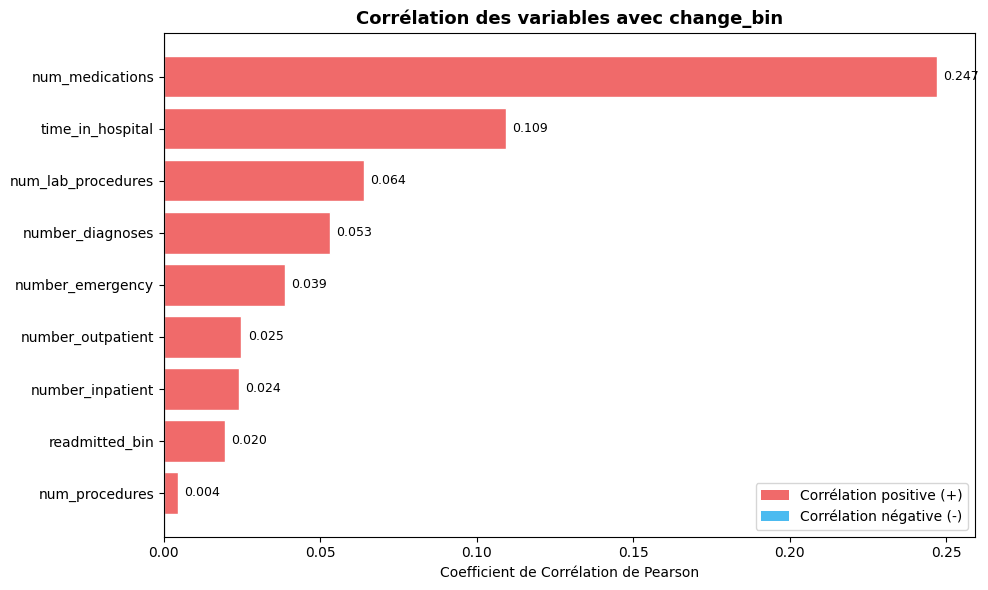

In [41]:
colonnes_numeriques = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'readmitted_bin', 'change_bin'
]

targets = ['readmitted_bin', 'change_bin']

plot_pearson_for_targets(df, targets, colonnes_numeriques)

#  ÉTAPE 9 : COLONNES MÉDICAMENTS
Dans cette étape, nous analysons les colonnes liées aux médicaments afin de comprendre les modifications de traitement chez les patients.

##Contexte

Le dataset contient **23 colonnes** représentant des médicaments, avec 4 valeurs possibles :

+ **No** : médicament non administré
+ **Steady** : dose stable
+ **Up** : augmentation de la dose
+ **Down** : diminution de la dose#

###Objectif

Nous cherchons à identifier :
quels médicaments sont les plus souvent modifiés


###Calcul des modifications

Pour chaque médicament, nous calculons le pourcentage de patients dont la dose a été modifiée :

+ soit **augmentation** (Up)
+ soit **diminution** (Down)

Cela permet de mesurer l’importance des ajustements de traitement.

###Visualisation

Nous utilisons un diagramme en barres horizontales pour afficher :

+ les médicaments
+ pourcentage de modification

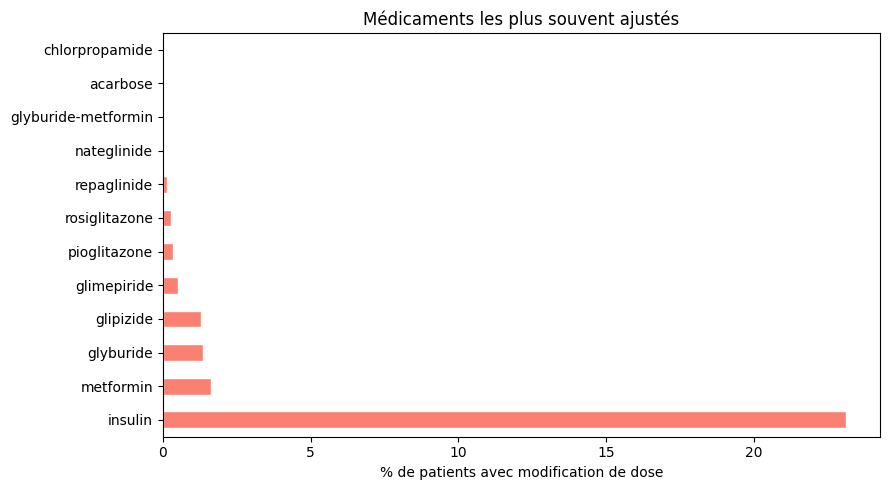

In [30]:
colonnes_medicaments = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin'
]

# Pourcentage de patients dont le médicament a été modifié (Up ou Down)
pct_modifie = (df[colonnes_medicaments]
               .apply(lambda col: col.isin(['Up', 'Down']).mean() * 100)
               .sort_values(ascending=False))

plt.figure(figsize=(9, 5))
pct_modifie.plot(kind='barh', color='salmon', edgecolor='white')
plt.xlabel('% de patients avec modification de dose')
plt.title('Médicaments les plus souvent ajustés')
plt.tight_layout()
plt.show()




#  ÉTAPE 10 : SYNTHÈSE FINALE
Dans cette étape, nous résumons les principales informations découvertes lors de l’analyse exploratoire des données (EDA).


In [31]:
print("⚛" * 55)
print("               SYNTHÈSE DE L'EDA")
print("⚛" * 55)
print(f"\n Nombre de lignes          : {len(df):,}")
print(f" Nombre de colonnes        : {df.shape[1]}")
print(f" Colonnes avec NaN         : {df.isnull().any().sum()}")
print(f" Doublons (encounter_id)   : {df['encounter_id'].duplicated().sum()}")
print(f"\n Cible readmitted_bin      : {df['readmitted_bin'].mean()*100:.1f}% positifs")
print(f" Cible change_bin          : {df['change_bin'].mean()*100:.1f}% positifs")
print(f"\n Colonnes à fort taux NaN  :")
for col in valeurs_manquantes[valeurs_manquantes['Pourcentage'] > 30].index:
    print(f"   - {col} ({valeurs_manquantes.loc[col, 'Pourcentage']:.1f}%)")
print("\n Prochaine étape : Nettoyage & Preprocessing")

  SYNTHÈSE DE L'EDA

 Nombre de lignes          : 101,766
 Nombre de colonnes        : 52
 Colonnes avec NaN         : 9
 Doublons (encounter_id)   : 0

 Cible readmitted_bin      : 11.2% positifs
 Cible change_bin          : 46.2% positifs

 Colonnes à fort taux NaN  :
   - weight (96.9%)
   - max_glu_serum (94.8%)
   - A1Cresult (83.3%)
   - medical_specialty (49.1%)
   - payer_code (39.6%)

 Prochaine étape : Nettoyage & Preprocessing
